DECISION TREE 

Objective --

The objective of this assignment is to apply Decision Tree Classification on the Heart Disease dataset, analyse the model performance, perform hyperparameter tuning, and interpret the results using various evaluation metrics and visualizations.

In [8]:
# Importing the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV

In [9]:
# Load Dataset

df = pd.read_excel("heart_disease.xlsx", sheet_name="Heart_disease")

# Displays First 5 Rows

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


# Explanation
1.Pandas and NumPy are used for data handling and numerical operations.
2.Matplotlib and Seaborn are used for data visualization.
3.Scikit-learn libraries are used for machine learning model building and evaluation.
4.The dataset is loaded using read_excel().

#Exploratory Data Analysis (EDA)

In [10]:
#shape
df.shape

(908, 13)

In [11]:
#columns
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [12]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [13]:
#missing values
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [14]:
# Statistical Summary
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


<!-- Explanation -->

EDA helps in understanding:

1.Structure of dataset
2.Data types
3.Missing values
4.Statistical distribution
5.Feature relationships

#DATA VISUALIZATION

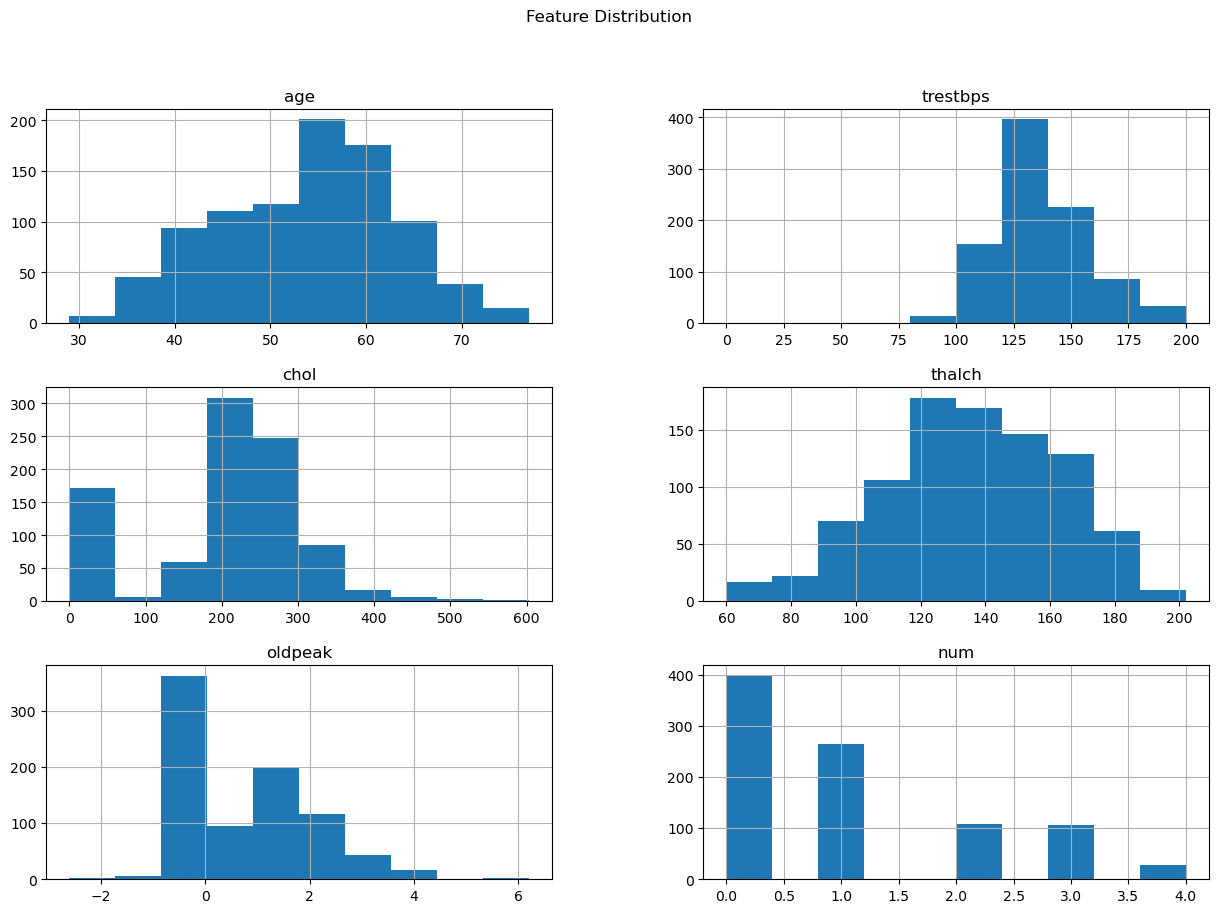

In [15]:
# Histogram 
df.hist(figsize=(15,10))

plt.suptitle("Feature Distribution")

plt.show()

Explanation: Histogram is used to visualize the distribution of numerical features.

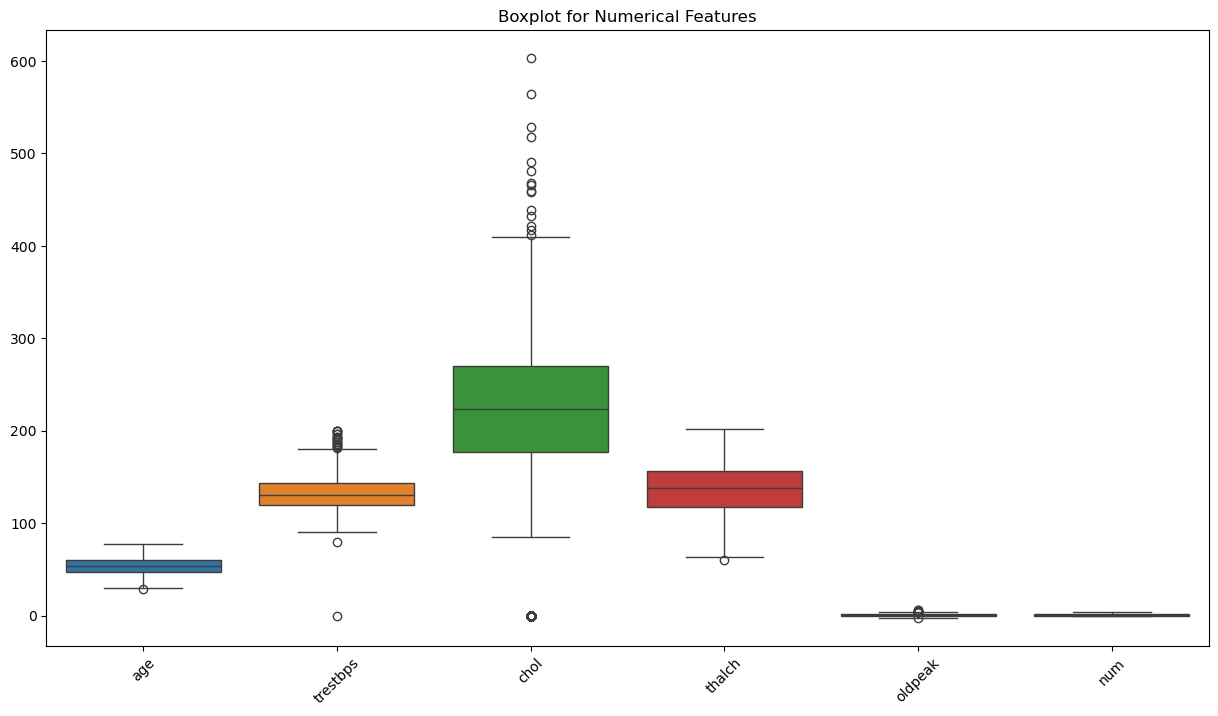

In [16]:
# Boxplot
plt.figure(figsize=(15,8))

sns.boxplot(data=df.select_dtypes(include=np.number))

plt.xticks(rotation=45)

plt.title("Boxplot for Numerical Features")

plt.show()

Explanation: Boxplots help identify outliers in the dataset.

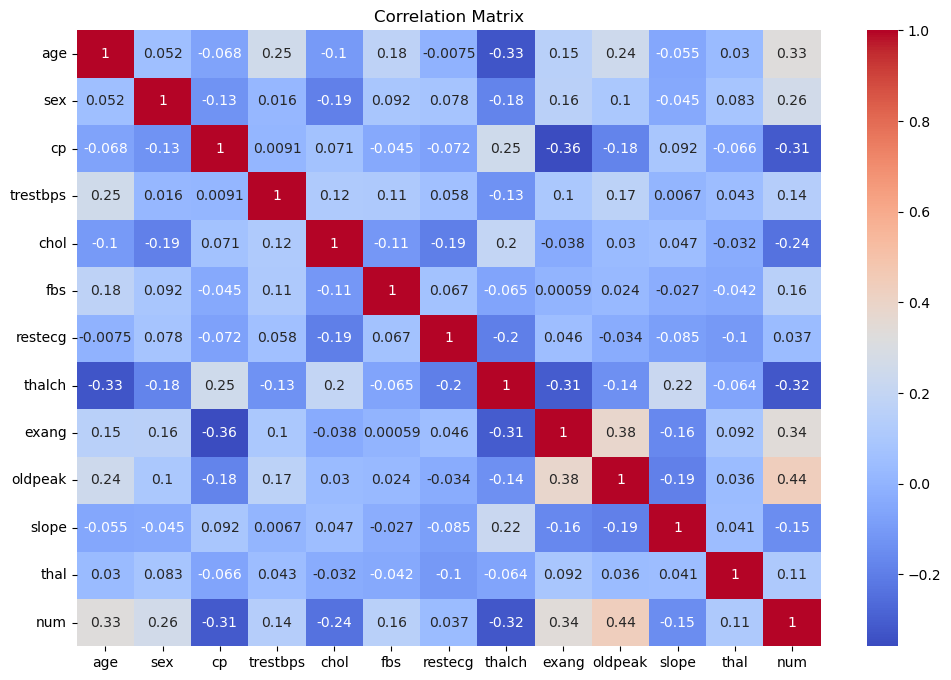

In [18]:
# Copy Dataset

df_corr = df.copy()

# Convert Boolean Columns to Integer

bool_cols = df_corr.select_dtypes(include='bool').columns

for col in bool_cols:
    df_corr[col] = df_corr[col].astype(int)

# Label Encoding for Object Columns

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

obj_cols = df_corr.select_dtypes(include='object').columns

for col in obj_cols:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# Correlation Matrix

plt.figure(figsize=(12,8))

sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

Explanation:

-->Correlation matrix shows the relationship between features.

--Positive correlation → variables increase together.
--Negative correlation → one variable increases while another decreases.

FEATURE ENGINEERING

In [20]:
# Create Copy of Dataset

df_encoded = df.copy()

# Convert Boolean Columns into Integer

bool_cols = df_encoded.select_dtypes(include='bool').columns

for col in bool_cols:
    df_encoded[col] = df_encoded[col].astype(int)

# Encode Object Columns

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

obj_cols = df_encoded.select_dtypes(include='object').columns

for col in obj_cols:
    df_encoded[col] = label_encoder.fit_transform(
        df_encoded[col].astype(str)
    )

# Check Dataset

df_encoded.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,1,2.3,0,0,0
1,41,1,1,135,203,0,1,132,1,0.0,1,0,0
2,57,1,0,140,192,0,1,148,1,0.4,1,0,0
3,52,1,3,118,186,0,0,190,1,0.0,1,0,0
4,57,1,0,110,201,0,1,126,3,1.5,1,0,0


Explanation:

Decision Tree requires numerical input, therefore categorical columns are converted into numerical form using Label Encoding.

In [21]:
# Define Features and Target Variable
# Features
X = df_encoded.drop("num", axis=1)
# Target
y = df_encoded["num"]
print(X.head())
print(y.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalch  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0     150      1      2.3      0   
1   41    1   1       135   203    0        1     132      1      0.0      1   
2   57    1   0       140   192    0        1     148      1      0.4      1   
3   52    1   3       118   186    0        0     190      1      0.0      1   
4   57    1   0       110   201    0        1     126      3      1.5      1   

   thal  
0     0  
1     0  
2     0  
3     0  
4     0  
0    0
1    0
2    0
3    0
4    0
Name: num, dtype: int64


Explanation:
*X contains input features
*y contains target variable (Heart Disease)

In [22]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (726, 12)
Testing Shape: (182, 12)


Explanation:

1.The dataset is divided into:
*80% Training Data
*20% Testing Data
--Training data is used for learning and testing data is used for evaluation.

In [23]:
# Decision Tree Model
from sklearn.tree import DecisionTreeClassifier

# Creating Model
dt_model = DecisionTreeClassifier(random_state=42)

# Training Model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Explanation:

The Decision Tree Classification model is created and trained using the training dataset.

In [25]:
# Prediction--- 
y_pred = dt_model.predict(X_test)
print(y_pred[:10])

[1 1 0 4 1 0 1 0 2 1]


Explanation:

The trained model predicts heart disease values for the test dataset.

In [26]:
# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

Accuracy Score: 0.5164835164835165

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.69      0.71        89
           1       0.40      0.44      0.42        48
           2       0.29      0.32      0.30        22
           3       0.31      0.29      0.30        17
           4       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.35      0.35      0.35       182
weighted avg       0.53      0.52      0.52       182


Confusion Matrix:

[[61 16  5  4  3]
 [15 21  7  4  1]
 [ 3  7  7  3  2]
 [ 4  7  1  5  0]
 [ 0  2  4  0  0]]


Explanation:
1.Accuracy--
Measures overall correctness of the model.

2.Precision--
Measures how many predicted positive values are actually positive.

3.Recall--
Measures how many actual positive cases are correctly identified.

4.F1-Score--
Balance between precision and recall.

5.Confusion Matrix--
Shows correct and incorrect classifications.

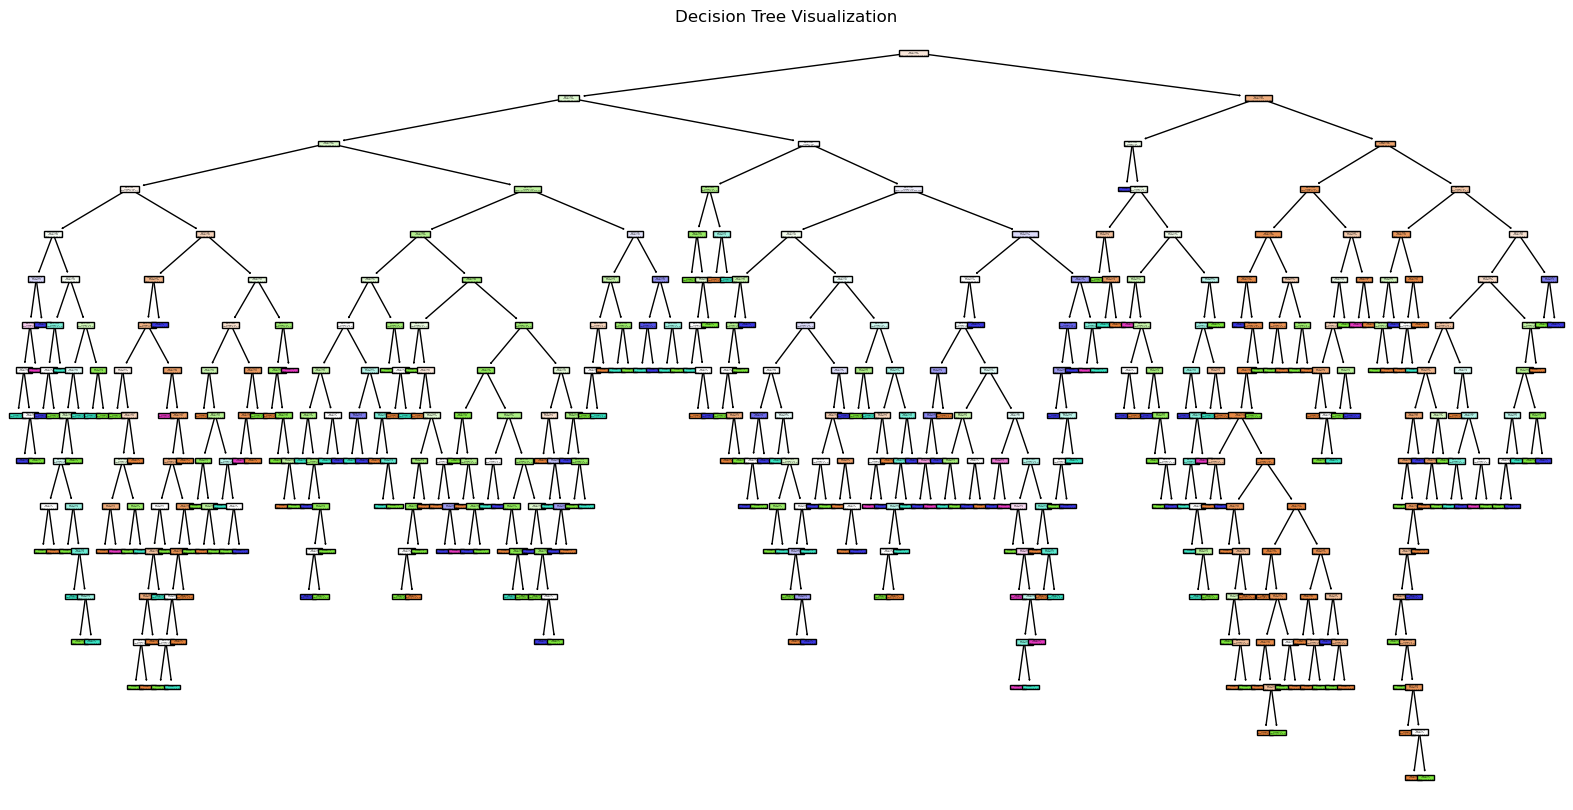

In [27]:
# Decision Tree Visualization
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    filled=True
)
plt.title("Decision Tree Visualization")
plt.show()

Explanation

Decision Tree visualization helps understand:

1.Decision rules
2.Splitting conditions
3.Important features
4.Model structure

     Feature  Importance
7     thalch    0.157466
4       chol    0.140207
0        age    0.134601
2         cp    0.127762
3   trestbps    0.115532
9    oldpeak    0.098236
6    restecg    0.053592
11      thal    0.045649
1        sex    0.035336
8      exang    0.035238
10     slope    0.032447
5        fbs    0.023932


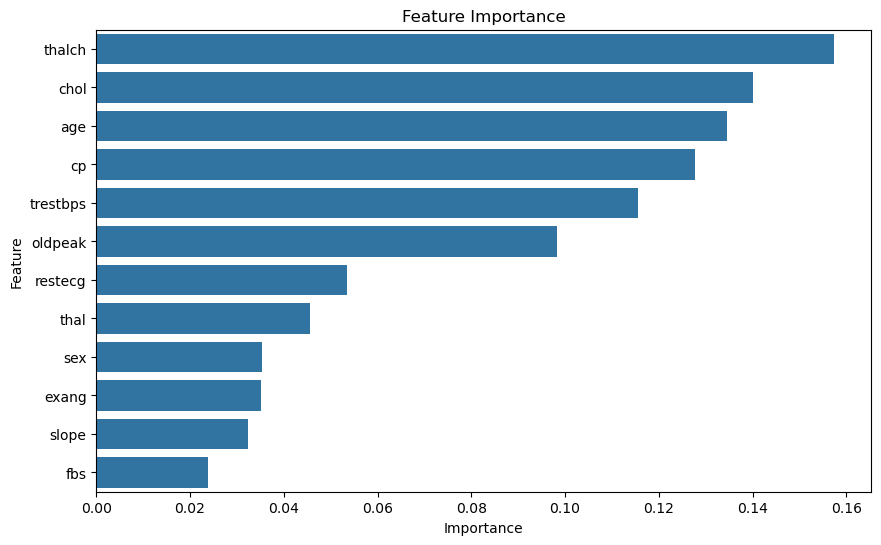

In [28]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

# Plot

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

Explanation

Feature importance identifies the most significant variables affecting heart disease prediction.

In [29]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Parameters
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}
# Grid Search
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)
# Train
grid_search.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}


Explanation:
Hyperparameter tuning improves model performance by finding the best parameter values.

-->Tuned Parameters
-->criterion
-->max_depth
-->min_samples_split

In [30]:
# Optimized Model
# Best Model
best_model = grid_search.best_estimator_

# Prediction
best_pred = best_model.predict(X_test)
# Accuracy

best_accuracy = accuracy_score(y_test, best_pred)
print("Optimized Accuracy:", best_accuracy)

Optimized Accuracy: 0.5659340659340659


Explanation:

The optimized Decision Tree model provides improved prediction performance compared to the default model.

Conclusion:

1.The Decision Tree Classification model was successfully implemented on the Heart Disease dataset. Exploratory Data Analysis helped in understanding the dataset structure and relationships among features.

2.Categorical features were converted into numerical values using Label Encoding. The dataset was divided into training and testing sets, and the Decision Tree model was trained successfully.

3.The model performance was evaluated using accuracy score, precision, recall, F1-score, and confusion matrix. Hyperparameter tuning further improved the performance of the model.

4.Feature importance analysis identified the most influential medical features affecting heart disease prediction. Overall, Decision Tree Classification proved to be an effective machine learning technique for predicting heart disease.